<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/AO1_Clase2_Vargas_Sandra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Situación problemática.**
Contexto del Problema
Una empresa de recursos humanos quiere analizar un conjunto de datos de empleados para identificar patrones en sueldos, edades y categorías
laborales.

El dataset contiene algunos problemas comunes, como valores faltantes, datos inconsistentes y variables categóricas sin codificar. Además, la
empresa quiere entender la relación entre edad, salario y nivel educativo.

In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder

# Creamos el DataFrame
datos = {
    "ID": [1, 2, 3, 4, 5],
    "Nombre": ["Juan", "Maria", "Pedro", "Ana", "Luis"],
    "Edad": [32, -28, 40, 35, 50],
    "Nivel_Educativo": ["Licenciado", "Ingeniero", "Doctorado", "Licenciado", "Doctorado"],
    "Salario": [50000, 60000, None, 55000, 200000],
    "Categoria": ["Junior", "Senior", "Senior", "Junior", "Manager"],
    "Estado": ["Activo", "ACTIVO", "Inactivo", "Activo", "Inactivo"]
}
df = pd.DataFrame(datos)
print(df)

   ID Nombre  Edad Nivel_Educativo   Salario Categoria    Estado
0   1   Juan    32      Licenciado   50000.0    Junior    Activo
1   2  Maria   -28       Ingeniero   60000.0    Senior    ACTIVO
2   3  Pedro    40       Doctorado       NaN    Senior  Inactivo
3   4    Ana    35      Licenciado   55000.0    Junior    Activo
4   5   Luis    50       Doctorado  200000.0   Manager  Inactivo


# **1. Identificación de Tipo de Datos.**
Clasifica cada columna según su tipo (numérico, categórico, ordinal, fecha) y explica cómo se debería manejar cada una.

In [281]:
# Inspeccionamos los tipos de datos
print(df.dtypes)

ID                   int64
Nombre              object
Edad                 int64
Nivel_Educativo     object
Salario            float64
Categoria           object
Estado              object
dtype: object


In [282]:
# Separar variables por tipo de dato Python, esto me ayudará a determinar el tratamiento a usar
numericas = df.select_dtypes(include=['number']).columns.tolist()
categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

print('Variables NUMÉRICAS:')
print(numericas)
print()
print('Variables CATEGÓRICAS:')
print(categoricas)
print()

Variables NUMÉRICAS:
['ID', 'Edad', 'Salario']

Variables CATEGÓRICAS:
['Nombre', 'Nivel_Educativo', 'Categoria', 'Estado']



# Clasificación de las variables según su naturaleza y tratamiento
***
RESUMEN:

• Los datos numéricos pueden usarse directamente en modelos de predicción.

• Los datos categóricos deben transformarse antes de usarse en algoritmos de Machine Learning.
***


ID: variable tipo numérica - No necesita transformación.

Nombre: variable tipo categórica nominal - No se analiza estadísticamente.

Edad: variable tipo numérica - Se observan valores negativos, requiere transformación usando el valor absoluto.

Nivel_Educativo: variable tipo categórica ordinal - Necesita transformación, se establece el siguiente orden: Licenciado < Ingeniero < Doctorado.

Salario: variable tipo numérica - Presenta faltante y outliers, es necesario normalizar.

Categoría: variable tipo categórica ordinal - Necesita transformación, se establece el siguiente orden: Junior < Senior < Manager.

Estado: variable tipo categórica nominal - Necesita transformación.

# **2. Limpieza de Datos**

• Detecta y corrige valores faltantes en las columnas necesarias.

• Identifica y elimina valores atípicos en la columna “Salario”.

• Corrige inconsistencias en los datos categóricos (ejemplo: "Licenciado" y "licenciado" deben ser tratados como el mismo valor).


In [283]:

# Comprobar filas con valor negativo en los datos de edad
print(df[df["Edad"] < 0])

   ID Nombre  Edad Nivel_Educativo  Salario Categoria  Estado
1   2  Maria   -28       Ingeniero  60000.0    Senior  ACTIVO


In [284]:
# 1 Corrección de edad negativa
df["Edad"] = df["Edad"].abs()
print(df)

   ID Nombre  Edad Nivel_Educativo   Salario Categoria    Estado
0   1   Juan    32      Licenciado   50000.0    Junior    Activo
1   2  Maria    28       Ingeniero   60000.0    Senior    ACTIVO
2   3  Pedro    40       Doctorado       NaN    Senior  Inactivo
3   4    Ana    35      Licenciado   55000.0    Junior    Activo
4   5   Luis    50       Doctorado  200000.0   Manager  Inactivo


In [285]:
# Detecta y corrige valores faltantes en las columnas necesarias.
print(df.isnull().sum())

ID                 0
Nombre             0
Edad               0
Nivel_Educativo    0
Salario            1
Categoria          0
Estado             0
dtype: int64


In [286]:
# 2 Imputación del salario faltante con la mediana
df['Salario'] = df['Salario'].fillna(df['Salario'].median())
print(df)

   ID Nombre  Edad Nivel_Educativo   Salario Categoria    Estado
0   1   Juan    32      Licenciado   50000.0    Junior    Activo
1   2  Maria    28       Ingeniero   60000.0    Senior    ACTIVO
2   3  Pedro    40       Doctorado   57500.0    Senior  Inactivo
3   4    Ana    35      Licenciado   55000.0    Junior    Activo
4   5   Luis    50       Doctorado  200000.0   Manager  Inactivo


In [287]:
# 3 Detectar y eliminar valores atípicos con IQR (Perdemos al Manager)
Q1, Q3 = df["Salario"].quantile([0.25, 0.75])
IQR = Q3 - Q1
df = df[~((df["Salario"] < (Q1 - 1.5 * IQR)) | (df["Salario"] > (Q3 + 1.5 * IQR)))]
print(df)

   ID Nombre  Edad Nivel_Educativo  Salario Categoria    Estado
0   1   Juan    32      Licenciado  50000.0    Junior    Activo
1   2  Maria    28       Ingeniero  60000.0    Senior    ACTIVO
2   3  Pedro    40       Doctorado  57500.0    Senior  Inactivo
3   4    Ana    35      Licenciado  55000.0    Junior    Activo


In [288]:
# Corregir inconsistencias en los datos categóricos
# uso str.capitalize() - Primera letra mayúscula, el resto minúscula
df["Nombre"] = df["Nombre"].str.capitalize()
df["Nivel_Educativo"] = df["Nivel_Educativo"].str.capitalize()
df["Categoria"] = df["Categoria"].str.capitalize()
df["Estado"] = df["Estado"].str.capitalize()
print(df)

   ID Nombre  Edad Nivel_Educativo  Salario Categoria    Estado
0   1   Juan    32      Licenciado  50000.0    Junior    Activo
1   2  Maria    28       Ingeniero  60000.0    Senior    Activo
2   3  Pedro    40       Doctorado  57500.0    Senior  Inactivo
3   4    Ana    35      Licenciado  55000.0    Junior    Activo


**3. Transformación de Datos**

• Convierte las variables categóricas en numéricas utilizando codificación ordinal o One-Hot Encoding.

• Aplica normalización al salario para facilitar comparaciones.

• Crea una nueva variable “Años hasta jubilación” suponiendo que la edad de retiro es 65 años.


In [289]:
# 4 Codificación ordinal para "Nivel Educativo"
encoder_educ = OrdinalEncoder(categories=[["Licenciado", "Ingeniero", "Doctorado"]])
df["Nivel_Cod_Educ"] = encoder_educ.fit_transform(df[["Nivel_Educativo"]])

# Codificación ordinal para "Categoría"
encoder_categ = OrdinalEncoder(categories=[["Junior", "Senior", "Manager"]])
df["Nivel_Cod_Cat"] = encoder_categ.fit_transform(df[["Categoria"]])

# Aplicar One-Hot Encoding para Estado
encoder_estado = OneHotEncoder(sparse_output=False, drop="first")
encoder_data = encoder_estado.fit_transform(df[["Estado"]])
# Convertir a DataFrame
df_encoded = pd.DataFrame(encoder_data, columns=encoder_estado.get_feature_names_out(["Estado"]))
df = pd.concat([df, df_encoded], axis=1)

# 5 Normalización del salario
scaler = MinMaxScaler()
df["Salario_Normalizado"] = scaler.fit_transform(df[["Salario"]])

# 6 Creación de nueva variable "Años hasta jubilación"
df["Años_Hasta_Jubilación"] = 65 - df["Edad"]

print(df)


   ID Nombre  Edad Nivel_Educativo  Salario Categoria    Estado  \
0   1   Juan    32      Licenciado  50000.0    Junior    Activo   
1   2  Maria    28       Ingeniero  60000.0    Senior    Activo   
2   3  Pedro    40       Doctorado  57500.0    Senior  Inactivo   
3   4    Ana    35      Licenciado  55000.0    Junior    Activo   

   Nivel_Cod_Educ  Nivel_Cod_Cat  Estado_Inactivo  Salario_Normalizado  \
0             0.0            0.0              0.0                 0.00   
1             1.0            1.0              0.0                 1.00   
2             2.0            1.0              1.0                 0.75   
3             0.0            0.0              0.0                 0.50   

   Años_Hasta_Jubilación  
0                     33  
1                     37  
2                     25  
3                     30  


**4. EDA con al menos dos visualizaciones y breve interpretación**

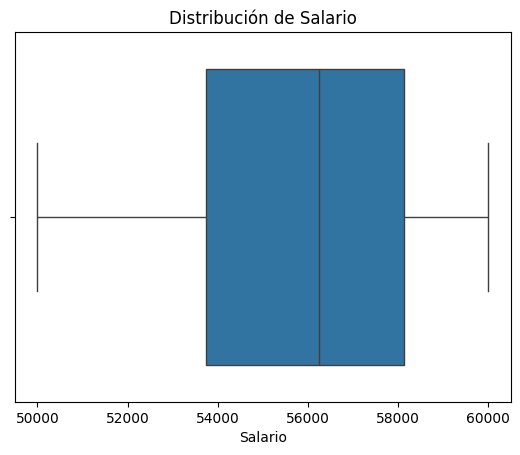

In [290]:
# Visualización 1 - Distribución de Salario (Boxplot)
sns.boxplot(x=df["Salario"])
plt.title("Distribución de Salario")
plt.show()

Podemos observar la districución de Salarios, caracterizados por las siguientes medidas:



*   Mínimo aprox $50.000


*   Máximo aprox $60.000


*   Mediana al rededor de $56.000

*   RI (Q1-Q3) entre $$54.000 y $58.000

Podemos decir que hay baja dispersión, no se observan outliers y como la mediana esta cerca del centro de la caja, no hay sesgo marcado, por lo cual la distribución es casi simétrica.

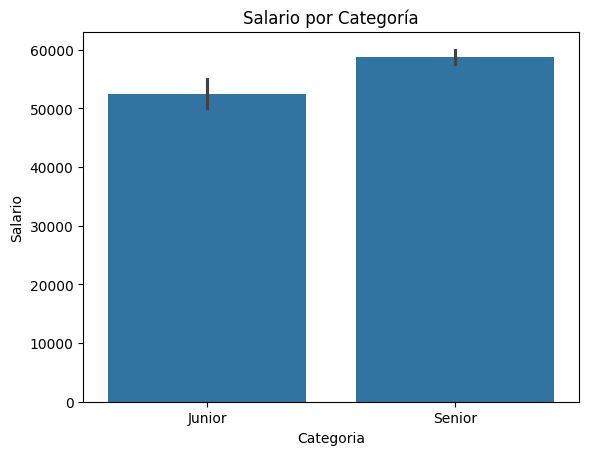

In [291]:
# Visualización 2 - Salario por categoría
sns.barplot(x=df["Categoria"], y=df["Salario"])
plt.title("Salario por Categoría")
plt.show()

Podemos observar que hay diferencia de salario entre ambas categorías, aproximadamente $$6.000. La categoría Junior, tiene un salario que ronda los $52.000. Mientras que la categoría Senior, tiene un salario promedio de $58.000.

Es comprensible que un Senior gane más que un Junior, ya que tiene mayor experiencia, responsabilidad.

**Análisis Exploratorio con LLM**

• Uso de LLM: 1–2 prompts y síntesis (3–5 líneas por prompt) de lo aportado, con validación propia.

Usa ChatGPT o una herramienta LLM para ayudarte en alguna de estas tareas:

• Generar un resumen de los datos.

• Explicar cómo manejar valores faltantes.

• Sugerir formas de visualizar los datos.

Ejemplo de consulta a ChatGPT: "Tengo un dataset con sueldos y edades, ¿cómo puedo detectar y eliminar outliers en Python?"

Comparte en el foro la consulta que hiciste y la respuesta que te dio el LLM.

*Trabajo compartido en la carpeta Semana 02/Trabajos en GitHub*
[link con la consulta a ChatGPT](https://github.com/SandraVargasAI/Mineria-de-Datos-/blob/main/Semana%2002/Trabajos/Foro%20-%20Consulta%20realizada%20a%20ChatGPT.pdf)
